# Logistic Regression & Maximum Likelihood Estimation

A mathematical walkthrough of Logistic Regression, Maximum Likelihood Estimation (MLE), Cross-Entropy Loss, and Gradient-Based Optimization.

---

## Table of Contents

* [1. Why Linear Regression Fails for Classification](#1-why-linear-regression-fails-for-classification)
* [2. The Logistic (Sigmoid) Function](#2-the-logistic-sigmoid-function)
* [3. Logistic Regression Hypothesis](#3-logistic-regression-hypothesis)
* [4. Decision Boundary](#4-decision-boundary)
* [5. Probabilistic Interpretation](#5-probabilistic-interpretation)
* [6. Maximum Likelihood Estimation (MLE)](#6-maximum-likelihood-estimation-mle)
* [7. Log-Likelihood](#7-log-likelihood)
* [8. Cross-Entropy Loss](#8-cross-entropy-loss)
* [9. Gradient Ascent](#9-gradient-ascent)
* [10. Gradient Descent Formulation](#10-gradient-descent-formulation)
* [11. Core Properties of Logistic Regression](#11-core-properties-of-logistic-regression)
* [Key Takeaways](#key-takeaways)

---

# 1. Why Linear Regression Fails for Classification

<details>
<summary><strong>Expand Section</strong></summary>

In binary classification,

$$
y \in {0,1}
$$

where:

* (0) = Negative class
* (1) = Positive class

A naive approach is

$$
h_\theta(x)=\theta^T x
$$

and classify using

$$
\hat y=
\begin{cases}
1 & h_\theta(x)\ge0.5 \
0 & \text{otherwise}
\end{cases}
$$

### Problems

#### 1. Sensitivity to Outliers

Linear regression minimizes squared error.

A few extreme observations can significantly alter the fitted line.

#### 2. Unbounded Predictions

$$
h_\theta(x)\in(-\infty,\infty)
$$

but probabilities require

$$
0 \le P(y=1|x) \le 1
$$

Therefore we need a bounded nonlinear transformation.

</details>

---

# 2. The Logistic (Sigmoid) Function

<details>
<summary><strong>Expand Section</strong></summary>

The sigmoid function is

$$
g(z)=\frac{1}{1+e^{-z}}
$$

It maps

$$
(-\infty,\infty)
\rightarrow
(0,1)
$$

### Properties

1. (z \to \infty \Rightarrow g(z)\to1)
2. (z \to -\infty \Rightarrow g(z)\to0)
3. (g(0)=0.5)

Derivative:

$$
g'(z)=g(z)(1-g(z))
$$

</details>

---

# 3. Logistic Regression Hypothesis

<details>
<summary><strong>Expand Section</strong></summary>

The logistic regression hypothesis is

$$
h_\theta(x)=g(\theta^Tx)
$$

or

$$
h_\theta(x)=
\frac{1}
{1+e^{-\theta^Tx}}
$$

Interpretation:

$$
h_\theta(x)
===========

P(y=1|x;\theta)
$$

and

$$
P(y=0|x;\theta)
===============

1-h_\theta(x)
$$

</details>

---

# 4. Decision Boundary

<details>
<summary><strong>Expand Section</strong></summary>

Classification is performed using

$$
\hat y=
\begin{cases}
1 & h_\theta(x)\ge0.5 \
0 & \text{otherwise}
\end{cases}
$$

Since

$$
g(0)=0.5
$$

the decision boundary occurs when

$$
\theta^T x = 0
$$

Thus logistic regression creates a **linear decision boundary**.

</details>

---

# 5. Probabilistic Interpretation

<details>
<summary><strong>Expand Section</strong></summary>

The model predicts

$$
P(y=1|x;\theta)
===============

h_\theta(x)
$$

and

$$
P(y=0|x;\theta)
===============

1-h_\theta(x)
$$

Both can be written compactly as

$$
P(y|x;\theta)
=============

(h_\theta(x))^y
(1-h_\theta(x))^{1-y}
$$

Verification:

### If (y=1)

$$
P(y|x;\theta)
=============

h_\theta(x)
$$

### If (y=0)

$$
P(y|x;\theta)
=============

1-h_\theta(x)
$$

</details>

---

# 6. Maximum Likelihood Estimation (MLE)

<details>
<summary><strong>Expand Section</strong></summary>

Given

$$
{
(x^{(1)},y^{(1)}),
\ldots,
(x^{(m)},y^{(m)})
}
$$

Likelihood is

$$
L(\theta)
=========

\prod_{i=1}^{m}
P(y^{(i)}|x^{(i)};\theta)
$$

Substituting logistic probabilities:

$$
L(\theta)
=========

\prod_{i=1}^{m}
(h_\theta(x^{(i)}))^{y^{(i)}}
(1-h_\theta(x^{(i)}))^{1-y^{(i)}}
$$

Goal:

$$
\max_\theta L(\theta)
$$

</details>

---

# 7. Log-Likelihood

<details>
<summary><strong>Expand Section</strong></summary>

Taking logarithms:

$$
\ell(\theta)
============

\log L(\theta)
$$

Expanding:

$$
\ell(\theta)
============

\sum_{i=1}^{m}
\left[
y^{(i)}
\log h_\theta(x^{(i)})
+
(1-y^{(i)})
\log(1-h_\theta(x^{(i)}))
\right]
$$

Since logarithm is monotonic,

$$
\arg\max L(\theta)
==================

\arg\max \ell(\theta)
$$

</details>

---

# 8. Cross-Entropy Loss

<details>
<summary><strong>Expand Section</strong></summary>

Machine learning frameworks typically minimize instead of maximize.

Define

$$
J(\theta)
=========

-\frac1m\ell(\theta)
$$

Then

$$
J(\theta)
=========

-\frac1m
\sum_{i=1}^{m}
\left[
y^{(i)}
\log h_\theta(x^{(i)})
+
(1-y^{(i)})
\log(1-h_\theta(x^{(i)}))
\right]
$$

This is called:

* Binary Cross-Entropy Loss
* Log Loss

</details>

---

# 9. Gradient Ascent

<details>
<summary><strong>Expand Section</strong></summary>

To maximize log-likelihood:

$$
\theta_j
\leftarrow
\theta_j
+
\alpha
\frac{\partial}
{\partial \theta_j}
\ell(\theta)
$$

The gradient is

$$
\frac{\partial}
{\partial \theta_j}
\ell(\theta)
============

\sum_{i=1}^{m}
(y^{(i)}-h_\theta(x^{(i)}))
x_j^{(i)}
$$

Therefore,

$$
\theta_j
\leftarrow
\theta_j
+
\alpha
\sum_{i=1}^{m}
(y^{(i)}-h_\theta(x^{(i)}))
x_j^{(i)}
$$

</details>

---

# 10. Gradient Descent Formulation

<details>
<summary><strong>Expand Section</strong></summary>

In practice we minimize Cross-Entropy Loss.

Gradient:

$$
\frac{\partial J(\theta)}
{\partial\theta_j}
==================

\frac1m
\sum_{i=1}^{m}
(h_\theta(x^{(i)})-y^{(i)})
x_j^{(i)}
$$

Update rule:

$$
\theta_j
\leftarrow
\theta_j
--------

\alpha
\frac{\partial J(\theta)}
{\partial\theta_j}
$$

This is the version used by:

* Scikit-Learn
* PyTorch
* TensorFlow
* JAX

</details>

---

# 11. Core Properties of Logistic Regression

<details>
<summary><strong>Expand Section</strong></summary>

## Convex Optimization

Cross-Entropy Loss is convex.

Therefore:

* No local minima
* Global optimum exists
* Gradient methods are reliable

## No Closed-Form Solution

Unlike linear regression:

$$
\theta=
(X^TX)^{-1}X^Ty
$$

Logistic regression has no analytical solution.

Optimization requires:

* Gradient Descent
* SGD
* Mini-Batch GD
* Newton's Method
* BFGS / L-BFGS

</details>

---

# Key Takeaways

* Logistic Regression is a probabilistic classifier.
* The sigmoid function converts arbitrary scores into probabilities.
* Maximum Likelihood Estimation determines optimal parameters.
* Cross-Entropy Loss is derived directly from MLE.
* Optimization is performed using Gradient Descent or Gradient Ascent.
* Logistic Regression produces a linear decision boundary.
* The optimization problem is convex and globally solvable.

---

## References

* Andrew Ng — Stanford CS229
* Stanford CS230 Deep Learning Notes
* Pattern Recognition and Machine Learning (Bishop)
* Machine Learning: A Probabilistic Perspective (Murphy)
* The Elements of Statistical Learning (Hastie, Tibshirani, Friedman)

---

**Author:** Nazmul Alam Diptu


In [12]:
"""
Logistic Regression using Batch Gradient Descent
------------------------------------------------

Binary Logistic Regression implemented from scratch using NumPy.

Features
--------
✓ Binary Cross Entropy Loss
✓ Batch Gradient Descent
✓ Accuracy Score
✓ Confusion Matrix
✓ Precision
✓ Recall
✓ F1 Score
✓ Decision Boundary Plot
✓ Loss Curve Plot

Author: Nazmul Alam Diptu
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt


class LogisticRegression:
    """
    Binary Logistic Regression using Batch Gradient Descent.
    """

    def __init__(
        self,
        learning_rate: float = 0.01,
        epochs: int = 1000,
    ) -> None:
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weight: np.ndarray | None = None
        self.bias: float = 0.0

        self.loss_history: list[float] = []

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def _binary_cross_entropy(
        y_true: np.ndarray,
        y_pred: np.ndarray,
    ) -> float:

        epsilon = 1e-15

        y_pred = np.clip(
            y_pred,
            epsilon,
            1 - epsilon,
        )

        loss = -np.mean(
            y_true * np.log(y_pred)
            + (1 - y_true) * np.log(1 - y_pred)
        )

        return float(loss)

    def fit(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> "LogisticRegression":

        x = np.asarray(x, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)

        if x.ndim == 1:
            x = x.reshape(-1, 1)

        n_samples, n_features = x.shape

        self.weight = np.zeros(n_features)
        self.bias = 0.0

        self.loss_history.clear()

        for _ in range(self.epochs):

            z = np.dot(x, self.weight) + self.bias

            y_pred = self._sigmoid(z)

            loss = self._binary_cross_entropy(
                y_true=y,
                y_pred=y_pred,
            )

            self.loss_history.append(loss)

            dw = (
                1 / n_samples
            ) * np.dot(
                x.T,
                (y_pred - y),
            )

            db = (
                1 / n_samples
            ) * np.sum(
                y_pred - y,
            )

            self.weight -= (
                self.learning_rate * dw
            )

            self.bias -= (
                self.learning_rate * db
            )

        return self

    def predict_proba(
        self,
        x: np.ndarray,
    ) -> np.ndarray:

        if self.weight is None:
            raise ValueError(
                "Model must be fitted before prediction."
            )

        x = np.asarray(
            x,
            dtype=np.float64,
        )

        if x.ndim == 1:
            x = x.reshape(-1, 1)

        z = np.dot(
            x,
            self.weight,
        ) + self.bias

        return self._sigmoid(z)

    def predict(
        self,
        x: np.ndarray,
        threshold: float = 0.5,
    ) -> np.ndarray:

        probabilities = self.predict_proba(x)

        return (
            probabilities >= threshold
        ).astype(int)

    def accuracy(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> float:

        predictions = self.predict(x)

        return float(
            np.mean(predictions == y)
        )

    def score(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> float:
        return self.accuracy(x, y)

    def confusion_matrix(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> np.ndarray:

        y_pred = self.predict(x)

        tp = np.sum(
            (y == 1) & (y_pred == 1)
        )

        tn = np.sum(
            (y == 0) & (y_pred == 0)
        )

        fp = np.sum(
            (y == 0) & (y_pred == 1)
        )

        fn = np.sum(
            (y == 1) & (y_pred == 0)
        )

        return np.array(
            [
                [tn, fp],
                [fn, tp],
            ]
        )

    def classification_report(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> dict:

        cm = self.confusion_matrix(x, y)

        tn, fp = cm[0]
        fn, tp = cm[1]

        precision = tp / (
            tp + fp + 1e-15
        )

        recall = tp / (
            tp + fn + 1e-15
        )

        f1 = (
            2
            * precision
            * recall
            / (
                precision
                + recall
                + 1e-15
            )
        )

        accuracy = (
            tp + tn
        ) / np.sum(cm)

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
        }

    def plot_loss(self) -> None:

        plt.figure(figsize=(8, 5))

        plt.plot(
            self.loss_history,
            linewidth=2,
        )

        plt.title(
            "Training Loss"
        )

        plt.xlabel("Epoch")

        plt.ylabel(
            """Binary Cross Entropy
            The Binary Cross-Entropy formula calculates `log(y_pred)` and `log(1 - y_pred)`. 
            If your model predicts an exact `0.0` or `1.0`, NumPy evaluates `log(0)`, which equals `-inf`. 
            Multiplying `-inf` by `0` yields `nan`, which corrupts your gradients and breaks training.
            
            ### The Fix
            Applying `np.clip(y_pred, {epsilon_val}, {1 - epsilon_val})` bounds your predictions 
            to a safe interval:
            * `0.0` becomes `{epsilon_val}` -> `log({epsilon_val})` evaluates safely to ~-34.54
            * `1.0` becomes `{1 - epsilon_val}`
            
            This keeps the math stable, the loss scalar clean, and the gradients valid.
            """
        )

        plt.grid(True)

        plt.show()

    def plot_decision_boundary(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> None:

        if x.shape[1] != 2:
            raise ValueError(
                "Decision boundary visualization "
                "requires exactly 2 features."
            )

        x_min, x_max = (
            x[:, 0].min() - 1,
            x[:, 0].max() + 1,
        )

        y_min, y_max = (
            x[:, 1].min() - 1,
            x[:, 1].max() + 1,
        )

        xx, yy = np.meshgrid(
            np.arange(
                x_min,
                x_max,
                0.05,
            ),
            np.arange(
                y_min,
                y_max,
                0.05,
            ),
        )

        grid = np.c_[
            xx.ravel(),
            yy.ravel(),
        ]

        predictions = self.predict(
            grid
        ).reshape(xx.shape)

        plt.figure(
            figsize=(8, 6)
        )

        plt.contourf(
            xx,
            yy,
            predictions,
            alpha=0.3,
        )

        plt.scatter(
            x[:, 0],
            x[:, 1],
            c=y,
            edgecolors="k",
        )

        plt.title(
            "Decision Boundary"
        )

        plt.xlabel(
            "Feature 1"
        )

        plt.ylabel(
            "Feature 2"
        )

        plt.show()

Accuracy: 0.8800

Confusion Matrix:
[[45  6]
 [ 6 43]]

Classification Report:
accuracy  : 0.8800
precision : 0.8776
recall    : 0.8776
f1_score  : 0.8776


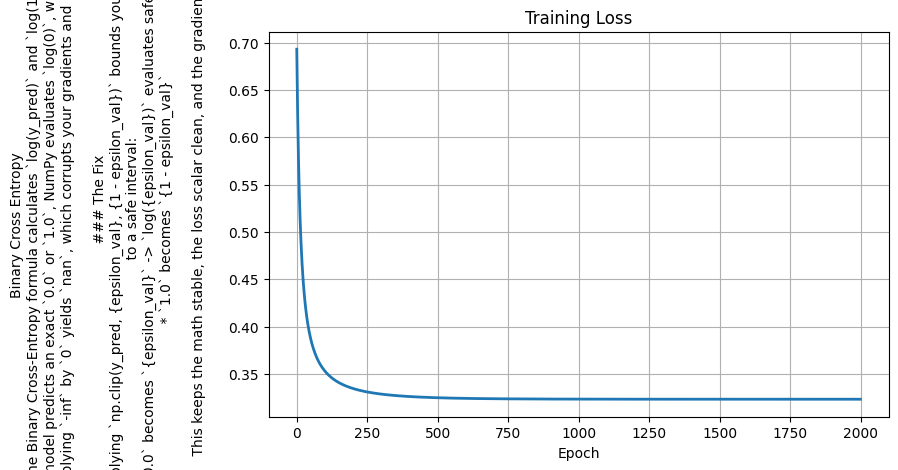

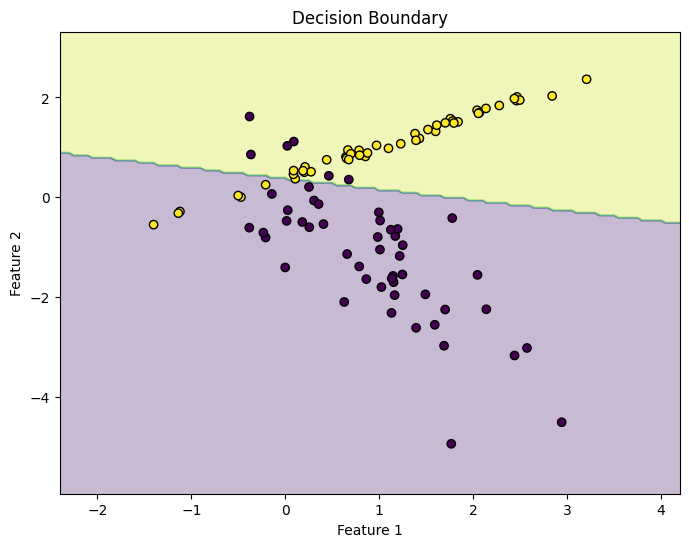

In [13]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create synthetic dataset
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42,
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# Train model
model = LogisticRegression(
    learning_rate=0.1,
    epochs=2000,
)

model.fit(
    X_train,
    y_train,
)

# Accuracy
accuracy = model.accuracy(
    X_test,
    y_test,
)

print(
    f"Accuracy: {accuracy:.4f}"
)

# Confusion Matrix
cm = model.confusion_matrix(
    X_test,
    y_test,
)

print("\nConfusion Matrix:")
print(cm)

# Classification Metrics
report = model.classification_report(
    X_test,
    y_test,
)

print("\nClassification Report:")

for metric, value in report.items():
    print(
        f"{metric:<10}: {value:.4f}"
    )

# Plot Loss Curve
model.plot_loss()

# Plot Decision Boundary
model.plot_decision_boundary(
    X_test,
    y_test,
)

## 1. Introduction to Classification & The Failure of Linear Regression

### 1.1 Classification Problems
In contrast to linear regression where the target variable $y$ is continuous, **classification problems** involve predicting a discrete-valued target variable $y$. 

Common binary classification examples include:
* **Email Spam Classification:** $y \in \{0, 1\}$ (0: Not Spam, 1: Spam)
* **Online Fraud Detection:** $y \in \{0, 1\}$ (0: Legitimate Transaction, 1: Fraudulent)
* **Tumor Malignancy Classification:** $y \in \{0, 1\}$ (0: Benign, 1: Malignant)

By convention:
* **$0$** represents the **negative class** (denoting the absence of a feature/condition, e.g., benign tumor).
* **$1$** represents the **positive class** (denoting the presence of a condition being searched for, e.g., malignant tumor).

*Note: The assignment of labels is arbitrary but standardizing on this intuition simplifies modeling.*


### 1.2 Why Linear Regression Fails for Classification
Applying standard ordinary least squares linear regression ($h_	heta(x) = 	heta^T x$) to discrete training sets and applying a threshold at $0.5$ (predicting $1$ if $h_	heta(x) \geq 0.5$, else $0$) is highly problematic for two major reasons:

1.  **Sensitivity to Outliers / Data Distribution Shifts:**
    If your data points are clustered compactly, linear regression might yield an acceptable decision boundary by chance. However, if a single positive training example appears far to the right (an outlier with a very large feature value), linear regression will twist its fitted line to minimize the squared error for that outlier. This shifts the threshold point drastically, resulting in a significantly worse decision boundary and misclassifying existing examples.
2.  **Unbounded Outputs:**
    Classification labels are strictly $0$ or $1$. Yet, a linear regression hypothesis can output values much larger than $1$ or less than $0$, which lacks structural meaning when predicting discrete classes.

---


## 2. Hypothesis Representation & The Sigmoid Function

To resolve the issue of unbounded outputs, logistic regression restricts the range of predictions to:

$$
0 \leq h_{\theta}(x) \leq 1
$$

### 2.1 The Sigmoid (Logistic) Function

Instead of setting

$$
h_{\theta}(x) = \theta^T x,
$$

we pass the linear combination through an activation function \( g(z) \):

$$
h_{\theta}(x) = g(\theta^T x)
$$

where \( g(z) \) is the **Sigmoid Function** (or **Logistic Function**):

$$
g(z) = \frac{1}{1 + e^{-z}}
$$

Combining these equations yields the logistic regression hypothesis:

$$
h_{\theta}(x)
=
\frac{1}{1 + e^{-\theta^T x}}
$$

### 2.2 Mathematical Properties of $g(z)$
* **Asymptotic Behavior:**
    $$\lim_{z 	o \infty} g(z) = 1$$
    $$\lim_{z 	o -\infty} g(z) = 0$$
* **Intercept:** At $z = 0$, $g(0) =  rac{1}{1+1} = 0.5$.

### 2.3 Probabilistic Interpretation
The output $h_	heta(x)$ is interpreted as the **estimated probability** that $y=1$ given the input features $x$, parameterized by $	heta$:

$$h_	heta(x) = P(y=1 \mid x; 	heta)$$

Since the target variable must be either $0$ or $1$, the conditional probabilities sum to $1$:

$$P(y=0 \mid x; 	heta) + P(y=1 \mid x; 	heta) = 1$$

Therefore, the probability of the negative class is computed directly as:

$$P(y=0 \mid x; 	heta) = 1 - h_	heta(x)$$

---

## 3. Decision Boundary

The **decision boundary** is the geometric line or surface that separates the region where the classifier predicts $y=1$ from the region where it predicts $y=0$.

### 3.1 Establishing Thresholds
A standard decision rule maps the continuous probability output to a discrete class:
* Predict $y=1$ if $h_	heta(x) \geq 0.5$
* Predict $y=0$ if $h_	heta(x) < 0.5$

By looking at the sigmoid function profile, $g(z) \geq 0.5$ whenever $z \geq 0$. Since $z = 	heta^T x$, this directly translates to:
* Predict $y=1$ whenever $	heta^T x \geq 0$
* Predict $y=0$ whenever $	heta^T x < 0$

### 3.2 Linear Decision Boundary Example
Consider a hypothesis with two features $x_1$ and $x_2$:

$$h_	heta(x) = g(	heta_0 + 	heta_1 x_1 + 	heta_2 x_2)$$

Suppose optimization yields the parameters $	heta = [-3, 1, 1]^T$. The model predicts $y=1$ when:

$$-3 + x_1 + x_2 \geq 0 \implies x_1 + x_2 \geq 3$$

The line $x_1 + x_2 = 3$ marks the exact boundary where $h_	heta(x) = 0.5$. It acts as the line of demarcation separating the two predicted classes.

### 3.3 Non-Linear Decision Boundaries via Polynomial Features
Just like in linear regression, higher-order polynomial features can be introduced into the feature vector $x$ to handle non-linearly separable datasets.

**Example (Circular Boundary):**
Let the hypothesis contain quadratic terms:

$$h_	heta(x) = g(	heta_0 + 	heta_1 x_1 + 	heta_2 x_2 + 	heta_3 x_1^2 + 	heta_4 x_2^2)$$

If the parameter vector is selected as $	heta = [-1, 0, 0, 1, 1]^T$, the model predicts $y=1$ when:

$$-1 + x_1^2 + x_2^2 \geq 0 \implies x_1^2 + x_2^2 \geq 1$$

The decision boundary is a unit circle centered at the origin. Points outside the circle are predicted as $y=1$, while points inside are predicted as $y=0$. By scaling up to even higher-order polynomials ($x_1^3, x_1^2x_2$, etc.), the boundary can adapt to irregular shapes (e.g., ellipses or arbitrary complex curves).

*CRITICAL INSIGHT:* The decision boundary is fundamentally a property of the **hypothesis and its parameters $	heta$**, not a property of the training dataset. The dataset is used exclusively to *fit* the parameters $	heta$. Once $	heta$ is locked in, the decision boundary is fully defined independently of the data.

---


## 4. Cost Function Construction

To fit the parameters $\theta$, we need an objective function that quantifies the penalty incurred by prediction errors.

### 4.1 The Issue with Squared Error (Non-Convexity)

In linear regression, the cost function is the Mean Squared Error (MSE):

$$
J(\theta)
=
\frac{1}{m}
\sum_{i=1}^{m}
\text{Cost}\big(h_\theta(x^{(i)}), y^{(i)}\big)
=
\frac{1}{m}
\sum_{i=1}^{m}
\frac{1}{2}
\left(
h_\theta(x^{(i)}) - y^{(i)}
\right)^2
$$

If we substitute the non-linear sigmoid hypothesis

$$
h_\theta(x)
=
\frac{1}{1 + e^{-\theta^T x}}
$$

into this squared error formulation, the resulting cost function $J(\theta)$ becomes **non-convex**.

A non-convex cost surface contains numerous local optima. If we run Gradient Descent, the algorithm can become trapped in a local minimum and fail to reach the global minimum.

We therefore require a **convex** objective function—a single bowl-shaped surface—so that Gradient Descent is guaranteed to converge to the global optimum.

### 4.2 The Logistic Regression Cost Function

To guarantee convexity, Logistic Regression employs a cost function derived from the statistical principle of **Maximum Likelihood Estimation (MLE)**.

The cost for a single training example is defined conditionally as:

$$
\text{Cost}\big(h_\theta(x), y\big)
=
\begin{cases}
-\log\!\big(h_\theta(x)\big),
& \text{if } y = 1 \\[8pt]
-\log\!\big(1 - h_\theta(x)\big),
& \text{if } y = 0
\end{cases}
$$

#### Mathematical Intent Analysis

**Case $y = 1$**

- If $h_\theta(x) \rightarrow 1$ (correct prediction),

$$
\text{Cost}
\rightarrow
-\log(1)
=
0
$$

- If $h_\theta(x) \rightarrow 0$ (incorrect prediction),

$$
\text{Cost}
\rightarrow
-\log(0)
\rightarrow
\infty
$$

**Intuition:** If a classifier predicts a $0\%$ probability that a tumor is malignant, but the tumor is actually malignant ($y=1$), the model receives an extremely large penalty.

---

**Case $y = 0$**

- If $h_\theta(x) \rightarrow 0$ (correct prediction),

$$
\text{Cost}
\rightarrow
-\log(1)
=
0
$$

- If $h_\theta(x) \rightarrow 1$ (incorrect prediction),

$$
\text{Cost}
\rightarrow
-\log(0)
\rightarrow
\infty
$$

**Intuition:** If a classifier predicts a $100\%$ probability that a tumor is malignant, but the tumor is actually benign ($y=0$), the model again receives an extremely large penalty.

---

The logarithmic penalty function strongly discourages confident but incorrect predictions while rewarding confident and correct predictions. This property makes it particularly suitable for probabilistic classification tasks.

## 5. Parameter Optimization & Gradient Descent

### 5.1 Compact Cost Function Expression

Because $y \in \{0,1\}$, we can combine the two conditional cases of the logistic regression cost function into a single compact expression:

$$
\text{Cost}\big(h_\theta(x), y\big)
=
-y \log\big(h_\theta(x)\big)
-
(1-y)\log\big(1-h_\theta(x)\big)
$$

Let's verify that this formula correctly reproduces the two cases:

- When $y = 1$:

$$
\text{Cost}
=
-1 \cdot \log\big(h_\theta(x)\big)
-
(1-1)\log\big(1-h_\theta(x)\big)
=
-\log\big(h_\theta(x)\big)
$$

- When $y = 0$:

$$
\text{Cost}
=
-0 \cdot \log\big(h_\theta(x)\big)
-
(1-0)\log\big(1-h_\theta(x)\big)
=
-\log\big(1-h_\theta(x)\big)
$$

Substituting this per-example cost into the overall training objective gives the complete logistic regression cost function:

$$
J(\theta)
=
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y^{(i)}
\log\big(h_\theta(x^{(i)})\big)
+
\big(1-y^{(i)}\big)
\log\big(1-h_\theta(x^{(i)})\big)
\right]
$$

This function is also known as the **Binary Cross-Entropy Loss** or **Log Loss**.

---

### 5.2 Gradient Descent Updates

To minimize $J(\theta)$, we use Gradient Descent.

At each iteration, every parameter $\theta_j$ is updated simultaneously according to:

$$
\theta_j
:=
\theta_j
-
\alpha
\frac{\partial}{\partial \theta_j}
J(\theta)
$$

where:

- $\alpha$ is the learning rate.
- $\frac{\partial}{\partial \theta_j}J(\theta)$ is the partial derivative of the cost function with respect to $\theta_j$.

After differentiating the logistic regression cost function, we obtain:

$$
\frac{\partial}{\partial \theta_j}
J(\theta)
=
\frac{1}{m}
\sum_{i=1}^{m}
\Big(
h_\theta(x^{(i)})
-
y^{(i)}
\Big)
x_j^{(i)}
$$

Substituting this derivative into the Gradient Descent update rule yields:

$$
\theta_j
:=
\theta_j
-
\frac{\alpha}{m}
\sum_{i=1}^{m}
\Big(
h_\theta(x^{(i)})
-
y^{(i)}
\Big)
x_j^{(i)}
$$

for all parameters $j = 0,1,\ldots,n$.

The optimization procedure can therefore be summarized as:

$$
\text{Repeat until convergence}
\left\{
\theta_j
:=
\theta_j
-
\frac{\alpha}{m}
\sum_{i=1}^{m}
\Big(
h_\theta(x^{(i)})
-
y^{(i)}
\Big)
x_j^{(i)}
\quad
\text{for all } j
\right\}
$$

---

### 5.3 Comparative Architectural Analysis

At first glance, the Gradient Descent update rule for Logistic Regression appears identical to the one used in Linear Regression.

However, the two algorithms differ fundamentally because they employ different hypothesis functions.

#### Linear Regression

$$
h_\theta(x)
=
\theta^T x
$$

- Produces continuous outputs.
- Suitable for regression tasks.
- Optimizes Mean Squared Error (MSE).

#### Logistic Regression

$$
h_\theta(x)
=
\frac{1}{1 + e^{-\theta^T x}}
$$

- Produces probabilities in the interval $(0,1)$.
- Suitable for classification tasks.
- Optimizes Log Loss (Cross-Entropy).

Although the update equations look similar, the prediction functions and cost functions are entirely different.

---

### 5.4 Implementation Strategies

#### Vectorization

Instead of updating each parameter individually using explicit loops, we can update the entire parameter vector simultaneously.

The vectorized Gradient Descent update is:

$$
\theta
:=
\theta
-
\frac{\alpha}{m}
X^T
\Big(
g(X\theta)
-
y
\Big)
$$

where:

- $X$ is the design matrix.
- $y$ is the target vector.
- $g(\cdot)$ denotes the sigmoid function.
- $\theta$ is the parameter vector.

Vectorization significantly improves computational efficiency and is the standard approach in modern machine learning libraries.

---

#### Feature Scaling

Gradient Descent converges much faster when input features are on similar numerical scales.

For example:

$$
x_1 \in [0,1]
\qquad\text{and}\qquad
x_2 \in [0,10000]
$$

can create highly elongated contours in the cost surface, causing slow convergence.

Common feature scaling techniques include:

**Z-Score Standardization**

$$
x_{\text{scaled}}
=
\frac{x-\mu}{\sigma}
$$

where:

- $\mu$ is the feature mean.
- $\sigma$ is the feature standard deviation.

**Min-Max Scaling**

$$
x_{\text{scaled}}
=
\frac{x-x_{\min}}
{x_{\max}-x_{\min}}
$$

which rescales values into the interval:

$$
[0,1]
$$

Feature scaling makes the optimization landscape more symmetric and enables Gradient Descent to converge more efficiently.

---

### Key Takeaways

1. Logistic Regression uses **Cross-Entropy Loss** instead of Mean Squared Error.
2. The resulting cost function is **convex**, making optimization reliable.
3. Gradient Descent updates parameters using the prediction error:

$$
h_\theta(x)-y
$$

4. The update equation resembles Linear Regression but operates on a sigmoid-based hypothesis.
5. Vectorization and feature scaling are essential for efficient training.

## 6. Advanced Optimization Algorithms

While gradient descent is straightforward, more sophisticated numerical optimization strategies exist.

### 6.1 Alternative Algorithms
* **Conjugate Gradient**
* **BFGS**
* **L-BFGS** (Limited-memory BFGS, optimized for massive feature dimensions)

### 6.2 Structural Advantages over Gradient Descent
1.  **No Manual Learning Rate ($ lpha$) Selection:** These algorithms use an internal loop mechanism known as a **line search algorithm**. This automatically evaluates alternative step sizes at every iteration to choose the most efficient step size dynamically.
2.  **Faster Convergence Speed:** They leverage advanced curvature calculations (or approximations of second derivatives), allowing them to step down complex cost valleys far quicker than basic gradient descent.

### 6.3 Disadvantages
* They are vastly more complex to implement from scratch.
* Debugging can be more difficult because numerical optimization libraries act as opaque black boxes.

*ENGINEERING SUGGESTION:* Never implement these advanced optimization algorithms yourself. Instead, rely on highly optimized, thoroughly tested numerical computing libraries (such as `fminunc` in Octave/MATLAB, or `scipy.optimize` in Python) to handle the underlying optimization.

---


## 7. Multi-Class Classification: One-vs-All

Binary classification handles problems with only two possible classes:

$$
y \in \{0,1\}
$$

However, many real-world classification tasks involve more than two categories. When the target variable can take one of multiple discrete values,

$$
y \in \{1,2,3,\ldots,K\}
$$

we have a **multi-class classification problem**.

### Examples

**Email Tagging**

- Work (1)
- Friends (2)
- Family (3)
- Hobby (4)

**Medical Diagnosis**

- Healthy (1)
- Cold (2)
- Flu (3)

**Weather Prediction**

- Sunny (1)
- Cloudy (2)
- Rainy (3)
- Snowy (4)

---

### 7.1 The One-vs-All (One-vs-Rest) Strategy

Logistic Regression is fundamentally a binary classifier. To extend it to multi-class problems, we use the **One-vs-All (OvA)** or **One-vs-Rest (OvR)** strategy.

The key idea is to train **one binary classifier for each class**.

For a problem with $K$ classes, we train $K$ separate logistic regression models.

Each classifier learns to distinguish:

- One specific class (**positive class = 1**)
- All remaining classes (**negative class = 0**)

---

#### Step 1: Train Classifier for Class 1

Create a new binary dataset:

$$
y =
\begin{cases}
1, & \text{if original class} = 1 \\
0, & \text{otherwise}
\end{cases}
$$

Train the classifier:

$$
h_{\theta}^{(1)}(x)
$$

This model answers:

> "What is the probability that this example belongs to Class 1?"

---

#### Step 2: Train Classifier for Class 2

Create another binary dataset:

$$
y =
\begin{cases}
1, & \text{if original class} = 2 \\
0, & \text{otherwise}
\end{cases}
$$

Train:

$$
h_{\theta}^{(2)}(x)
$$

This model answers:

> "What is the probability that this example belongs to Class 2?"

---

#### Continue for All Classes

Repeat the same process until Class $K$.

The final collection of classifiers becomes:

$$
h_{\theta}^{(1)}(x),
\quad
h_{\theta}^{(2)}(x),
\quad
\ldots,
\quad
h_{\theta}^{(K)}(x)
$$

Each classifier has its own parameter vector:

$$
\theta^{(1)},
\theta^{(2)},
\ldots,
\theta^{(K)}
$$

and is trained independently.

---

### Mathematical Interpretation

Each classifier estimates the probability that the input belongs to its corresponding class:

$$
h_{\theta}^{(i)}(x)
=
P(y=i \mid x;\theta^{(i)})
\qquad
\text{for }
i=1,2,\ldots,K
$$

where:

- $P(y=i \mid x;\theta^{(i)})$ is the probability that input $x$ belongs to class $i$.
- $\theta^{(i)}$ denotes the parameter vector for classifier $i$.

---

### Example: Three-Class Problem

Suppose we have three classes:

$$
y \in \{1,2,3\}
$$

We train three separate logistic regression models:

| Classifier | Positive Class | Negative Class |
|------------|----------------|----------------|
| $h_\theta^{(1)}(x)$ | Class 1 | Classes 2 and 3 |
| $h_\theta^{(2)}(x)$ | Class 2 | Classes 1 and 3 |
| $h_\theta^{(3)}(x)$ | Class 3 | Classes 1 and 2 |

After training, each classifier specializes in recognizing its own class.

---

### 7.2 Making Predictions

Suppose a new data point $x$ arrives.

We pass the same input through **all $K$ classifiers**:

$$
h_{\theta}^{(1)}(x)
$$

$$
h_{\theta}^{(2)}(x)
$$

$$
\vdots
$$

$$
h_{\theta}^{(K)}(x)
$$

Each classifier returns a probability estimate.

For example:

$$
h_{\theta}^{(1)}(x)=0.15
$$

$$
h_{\theta}^{(2)}(x)=0.72
$$

$$
h_{\theta}^{(3)}(x)=0.10
$$

The second classifier produces the highest probability, so we predict:

$$
\hat{y}=2
$$

---

### Formal Decision Rule

The predicted class is the one whose classifier outputs the largest probability:

$$
\hat{y}
=
\arg\max_{i}
h_{\theta}^{(i)}(x)
$$

where:

- $\arg\max$ means "return the index of the largest value."
- $i$ ranges from $1$ to $K$.

This rule selects the classifier that is most confident about the input's class membership.

---

### Visual Intuition

For a three-class problem:

| Classifier | Output Probability |
|------------|-------------------|
| $h_\theta^{(1)}(x)$ | 0.20 |
| $h_\theta^{(2)}(x)$ | 0.65 |
| $h_\theta^{(3)}(x)$ | 0.15 |

Since

$$
0.65
=
\max(0.20,0.65,0.15)
$$

the final prediction becomes:

$$
\hat{y}=2
$$

---

### Advantages of One-vs-All

1. Simple to implement.
2. Uses standard binary Logistic Regression.
3. Scales naturally to multiple classes.
4. Easy to interpret because each classifier specializes in a single class.
5. Works well when the number of classes is relatively small.

---

### Limitations

1. Requires training $K$ separate models.
2. Training cost increases as the number of classes grows.
3. Probability estimates from different classifiers may not always be perfectly calibrated.
4. Modern deep learning systems often prefer **Softmax Regression (Multinomial Logistic Regression)** for large-scale multi-class problems.

---

### Key Takeaways

1. Logistic Regression is inherently a binary classifier.
2. Multi-class problems can be solved using the **One-vs-All (OvA)** strategy.
3. For $K$ classes, we train $K$ independent binary classifiers.
4. Each classifier estimates:

$$
P(y=i \mid x)
$$

5. Final prediction is obtained using:

$$
\hat{y}
=
\arg\max_i
h_{\theta}^{(i)}(x)
$$

6. One-vs-All is one of the most important extensions of Logistic Regression and serves as a foundation for understanding more advanced multi-class methods such as Softmax Regression.